# step 1 : library imports and load data
In this section, we import necessary libraries for data manipulation and visualization. We also load the train.csv and store.csv datasets.

In [18]:
!git clone https://github.com/ML-Proj-Team/Rossmann_Sales.git


Cloning into 'Rossmann_Sales'...
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 14 (delta 1), reused 13 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (14/14), 7.43 MiB | 10.55 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [19]:
%cd /content/Rossmann_Sales/dataset


/content/Rossmann_Sales/dataset


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
# Load the datasets
train = pd.read_csv('train.csv', low_memory=False)
store = pd.read_csv('store.csv')

print("Data loaded successfully.")

Data loaded successfully.


# step 2 : data merging

We merge the train and store dataframes on the Store column.
This allows us to:

1- analyze how store-specific features (like StoreType) affect sales performance.

2- convert the Date column to a proper datetime format.

In [22]:
# Convert Date to datetime
train['Date'] = pd.to_datetime(train['Date'])

# Merge datasets
df = pd.merge(train, store, on='Store')
df.head()


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


# Step 3: Sales Trend Analysis (task 1)
We visualize the daily sales trend to identify patterns and seasonality. We will compare the sales of three different stores over time.

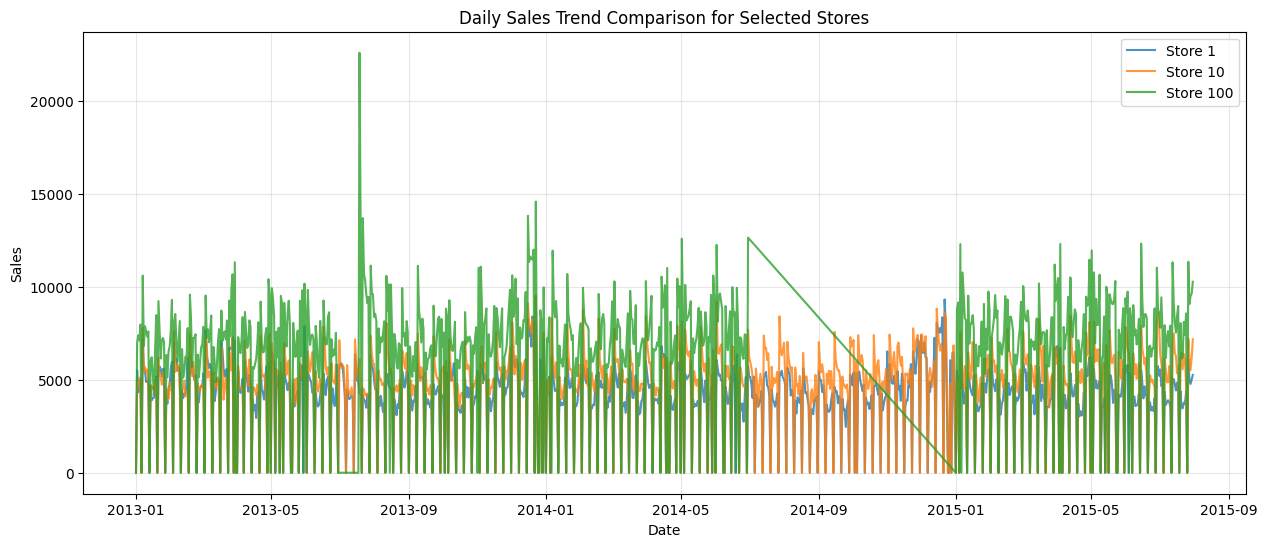

In [23]:
# Visualizing Sales Trend over time for sample stores
plt.figure(figsize=(15, 6))

# Selecting 3 sample stores
sample_stores = [1, 10, 100]

for s in sample_stores:
    store_data = df[df['Store'] == s].sort_values('Date')
    plt.plot(store_data['Date'], store_data['Sales'], label=f'Store {s}', alpha=0.8)

plt.title('Daily Sales Trend Comparison for Selected Stores')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## visualization clearer and reduce noise

1- Exclude days when stores were **closed**.

2- Apply a 7-day **rolling average** to smooth out daily fluctuations and highlight the underlying sales trend.

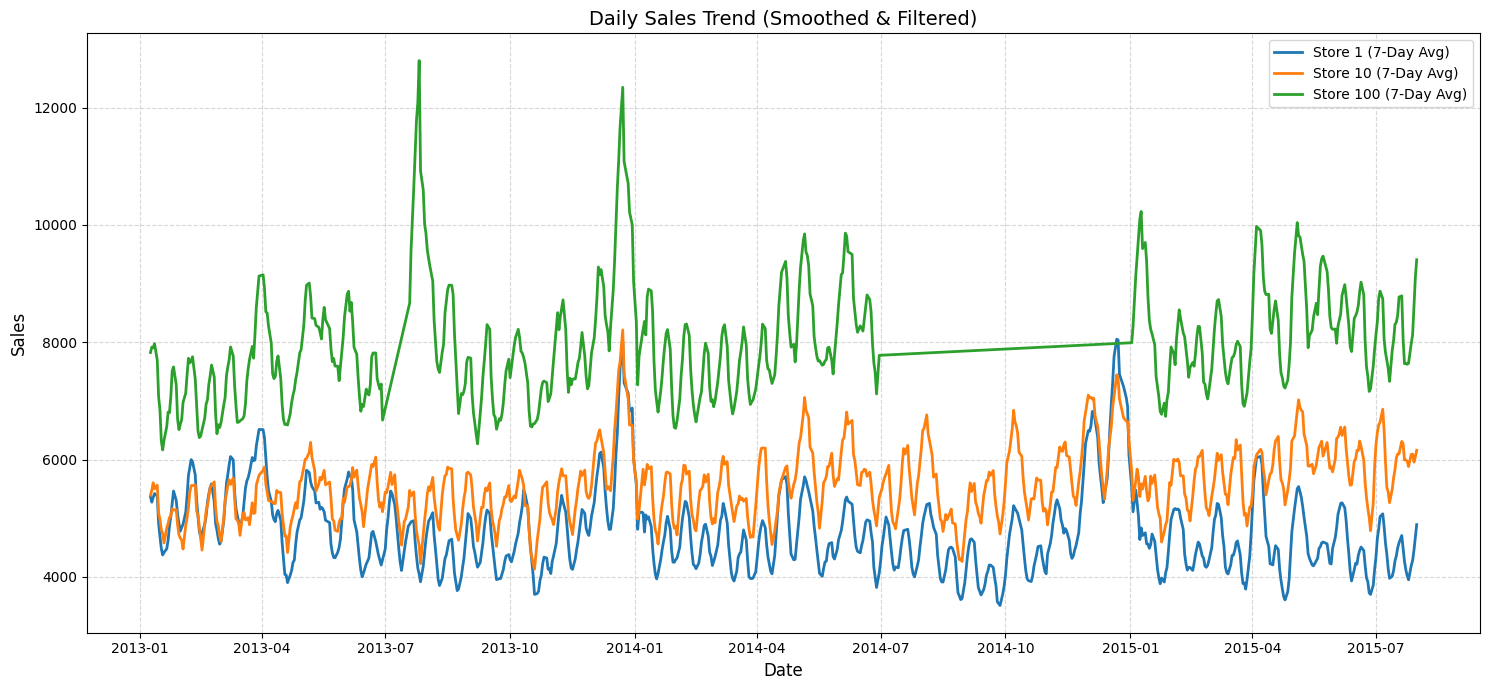

In [24]:
plt.figure(figsize=(15, 7))

# Selecting sample stores to compare
sample_stores = [1, 10, 100]

for s in sample_stores:
    # Filter data for the specific store
    store_data = df[df['Store'] == s].sort_values('Date').copy()

    # IMPORTANT: Remove days where store was closed to clean the chart
    store_data = store_data[store_data['Open'] != 0]

    # Calculate 7-day rolling average for smoothing
    store_data['Sales_Moving_Avg'] = store_data['Sales'].rolling(window=7).mean()

    # Plot the smoothed data
    plt.plot(store_data['Date'], store_data['Sales_Moving_Avg'], label=f'Store {s} (7-Day Avg)', linewidth=2)

plt.title('Daily Sales Trend (Smoothed & Filtered)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# step 4 : impact of promotions (task 2)

/tmp/ipython-input-3746853951.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Promo', y='Sales', palette='viridis')


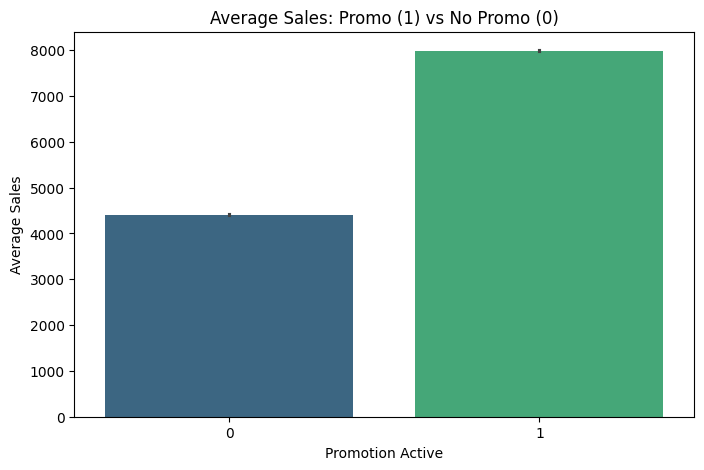

In [25]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Promo', y='Sales', palette='viridis')
plt.title('Average Sales: Promo (1) vs No Promo (0)')
plt.xlabel('Promotion Active')
plt.ylabel('Average Sales')
plt.show()

# Step 5: Correlation Matrix (Task 3)
We use a heatmap to visualize the correlation between numerical features. This helps us understand which variables (like Customers or Promo) have the strongest relationship with Sales.

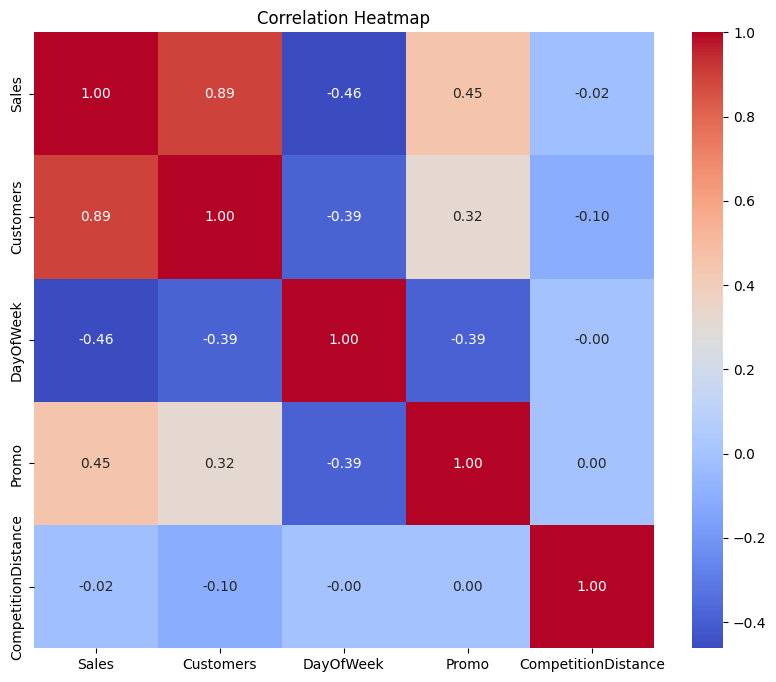

In [26]:
plt.figure(figsize=(10, 8))
# Analyzing key numerical features
cols_to_corr = ['Sales', 'Customers', 'DayOfWeek', 'Promo', 'CompetitionDistance']
correlation = df[cols_to_corr].corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


**# phase 2**



Step 1: Merging Tables & Handling Missing Data
Implemented Requirements:

● Merging sales and store tables based on Store ID.
● Normalization and Handling Missing Data.

In [39]:
import pandas as pd
import numpy as np

print("--- Step 1: Merging & Cleaning ---")

# 1. Merge tables
df = pd.merge(train, store, on='Store', how='left')

# 2. Handle Missing Data
# Fill NaN with Median
df['CompetitionDistance'] = df['CompetitionDistance'].fillna(df['CompetitionDistance'].median())

cols_to_fill_zero = ['CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear',
                     'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']
df[cols_to_fill_zero] = df[cols_to_fill_zero].fillna(0)

print(f"Merged Data Shape: {df.shape}")
print(df[['Store', 'Date', 'Sales', 'CompetitionDistance', 'StoreType']].head())


--- Step 1: Merging & Cleaning ---
Merged Data Shape: (1017209, 18)
   Store       Date  Sales  CompetitionDistance StoreType
0   1115 2013-01-01      0               5350.0         d
1    379 2013-01-01      0               6630.0         d
2    378 2013-01-01      0               2140.0         a
3    377 2013-01-01      0                100.0         a
4    376 2013-01-01      0                160.0         a


Cell 2: Time Features & Cyclical Features (Fourier)
Implemented Requirements:

● Creating New Time Features (Day of Week, Month, Holiday, etc.).
● Extracting Cyclical Features (Fourier terms for Seasonality).


In [40]:
print("\n--- Step 2: Time & Cyclical Features ---")

# 1. Extract Basic Time Features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['WeekOfYear'] = df['Date'].dt.isocalendar().week

df['DayOfWeek_Sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
df['DayOfWeek_Cos'] = np.cos(2 * np.pi * df['DayOfWeek'] / 7)

# Yearly Seasonality
df['Month_Sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_Cos'] = np.cos(2 * np.pi * df['Month'] / 12)

# 3. Encoding Categorical Variables
# Mapping characters 'a', 'b', 'c', 'd' to numbers
mappings = {'0':0, 'a':1, 'b':2, 'c':3, 'd':4}
df['StoreType'] = df['StoreType'].map(mappings)
df['Assortment'] = df['Assortment'].map(mappings)

df['StateHoliday'] = df['StateHoliday'].astype(str).map({'0':0, 'a':1, 'b':2, 'c':3}).fillna(0)

print(df[['Date', 'Month', 'Month_Sin', 'Month_Cos', 'StateHoliday']].head())



--- Step 2: Time & Cyclical Features ---
        Date  Month  Month_Sin  Month_Cos  StateHoliday
0 2013-01-01      1        0.5   0.866025             1
1 2013-01-01      1        0.5   0.866025             1
2 2013-01-01      1        0.5   0.866025             1
3 2013-01-01      1        0.5   0.866025             1
4 2013-01-01      1        0.5   0.866025             1


Cell 3: Lag Features & Rolling Statistics
Implemented Requirements:

● Creating Lag Features (Sales of previous days).
● Creating Rolling Statistics (Moving Average of last 7 days, Standard Deviation, etc.).

In [41]:
print("\n--- Step 3: Lag & Rolling Features ---")

# Sort by Store and Date to ensure shifts are correct
df = df.sort_values(['Store', 'Date'])

# Group by Store so calculations don't bleed between different stores
grouped = df.groupby('Store')['Sales']

# 1. Lag Features (Past Sales)
# Sales from 1 day ago
df['Sales_Lag_1'] = grouped.shift(1)
# Sales from 7 days ago (Same day last week)
df['Sales_Lag_7'] = grouped.shift(7)

# 2. Rolling Statistics (Moving Windows)
# Average Sales of the last 7 days (Shifted by 1 to prevent data leakage)
df['Sales_Rolling_Mean_7'] = grouped.shift(1).rolling(window=7).mean()
# Standard Deviation of the last 7 days (Volatility)
df['Sales_Rolling_Std_7'] = grouped.shift(1).rolling(window=7).std()

# Drop rows with NaN created by lagging (the first 7 days of data)
df = df.dropna()

# Display result
print(df[['Store', 'Date', 'Sales', 'Sales_Lag_1', 'Sales_Rolling_Mean_7']].head())



--- Step 3: Lag & Rolling Features ---
       Store       Date  Sales  Sales_Lag_1  Sales_Rolling_Mean_7
8081       1 2013-01-08   5580       7176.0           3788.000000
9285       1 2013-01-09   5471       5580.0           4585.142857
10401      1 2013-01-10   4892       5471.0           4576.714286
11515      1 2013-01-11   4881       4892.0           4657.428571
12631      1 2013-01-12   4952       4881.0           4713.857143


Cell 4: Normalization & Time-Based Split
Implemented Requirements:

● Normalization (Log Transformation of Target).
● Splitting Data into Train/Validation/Test while Preserving Time Order.

In [42]:
print("\n--- Step 4: Normalization & Splitting ---")

# 1. Target Normalization (Log Transform)
# We use Log(Sales + 1) to handle skewness and zero values
df['Log_Sales'] = np.log1p(df['Sales'])

# 2. Define Feature List
features = [
    'Store', 'Promo', 'StateHoliday', 'SchoolHoliday',
    'StoreType', 'Assortment', 'CompetitionDistance',
    'DayOfWeek', 'Month', 'Year', 'Day', 'WeekOfYear',
    'DayOfWeek_Sin', 'DayOfWeek_Cos', 'Month_Sin', 'Month_Cos',
    'Sales_Lag_1', 'Sales_Lag_7',
    'Sales_Rolling_Mean_7', 'Sales_Rolling_Std_7'
]
target = 'Log_Sales'

# 3. Time-Based Split
# Reserve the last 6 weeks for Testing
cutoff_date = df['Date'].max() - pd.Timedelta(days=6*7)

train_data = df[df['Date'] < cutoff_date]
test_data = df[df['Date'] >= cutoff_date]

# Create Final Feature Matrices
X_train = train_data[features]
y_train = train_data[target]
X_test = test_data[features]
y_test = test_data[target]

print(f"Cutoff Date: {cutoff_date}")
print(f"Train Set Shape: {X_train.shape}")
print(f"Test Set Shape:  {X_test.shape}")
print("Phase 2 Complete. Data is ready for Modeling (Phase 3).")



--- Step 4: Normalization & Splitting ---


/tmp/ipython-input-3544096528.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Log_Sales'] = np.log1p(df['Sales'])


Cutoff Date: 2015-06-19 00:00:00
Train Set Shape: (961459, 20)
Test Set Shape:  (47945, 20)
Phase 2 Complete. Data is ready for Modeling (Phase 3).


# **Phase 3**

Cell 1: Baseline Model (Linear Regression)
Implemented Requirements:

We use a simple Linear Regression. If our complex XGBoost model cannot beat this simple model later, then the complex model is useless.

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

print("--- Step 1: Baseline Model (Linear Regression) ---")

# 1. Initialize and Train
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 2. Predict
y_pred_log_lr = lr_model.predict(X_test)

# 3. Inverse Transform (Log -> Real Sales) to calculate real error
y_test_real = np.expm1(y_test)
y_pred_real_lr = np.expm1(y_pred_log_lr)

# 4. Evaluation
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_log_lr))
mae_real_lr = mean_absolute_error(y_test_real, y_pred_real_lr)

print(f"Baseline RMSE (Log Scale): {rmse_lr:.4f}")
print(f"Baseline MAE (Real Currency): {mae_real_lr:.2f}")
print("Baseline established. Advanced models must beat these scores.")


--- Step 1: Baseline Model (Linear Regression) ---
Baseline RMSE (Log Scale): 1.0618
Baseline MAE (Real Currency): 4721.87
Baseline established. Advanced models must beat these scores.


Cell 2: Store-Aware Time-Series Cross-Validation
Implemented Requirements:

Standard k-fold is wrong for time series because it shuffles future and past. We implement a custom “Rolling Window” or “Expanding Window” split. We train on the first few months, validate on the next month, then expand the training set.

In [45]:
import xgboost as xgb
import numpy as np

print("\n--- Step 2: Time-Series Cross-Validation (Store-Aware) ---")

# FIX: Use np.sort() to sort the array safely
dates = train_data['Date'].unique()
dates = np.sort(dates)

split_1 = int(len(dates) * 0.7)
split_2 = int(len(dates) * 0.85)
split_indices = [split_1, split_2]

cv_scores = []

params = {
    'objective': 'reg:squarederror',
    'eta': 0.1,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42
}


for i, split_idx in enumerate(split_indices):
    split_date = dates[split_idx]

    # Create fold masks locally
    # Training: All data BEFORE the split date
    mask_train = train_data['Date'] < split_date


    end_idx = min(split_idx + 14, len(dates) - 1)
    end_date = dates[end_idx]

    mask_val = (train_data['Date'] >= split_date) & (train_data['Date'] < end_date)

    # Get data for this fold
    X_tr_fold = train_data.loc[mask_train, features]
    y_tr_fold = train_data.loc[mask_train, target]
    X_val_fold = train_data.loc[mask_val, features]
    y_val_fold = train_data.loc[mask_val, target]

    # Train
    dtrain = xgb.DMatrix(X_tr_fold, label=y_tr_fold)
    dval = xgb.DMatrix(X_val_fold, label=y_val_fold)
    model_fold = xgb.train(params, dtrain, num_boost_round=50, verbose_eval=False)

    # Predict
    preds = model_fold.predict(dval)
    rmse = np.sqrt(mean_squared_error(y_val_fold, preds))
    cv_scores.append(rmse)

    print(f"Fold {i+1} (Train up to {str(split_date)[:10]}): RMSE = {rmse:.4f}")

print(f"Average CV RMSE: {np.mean(cv_scores):.4f}")



--- Step 2: Time-Series Cross-Validation (Store-Aware) ---
Fold 1 (Train up to 2014-09-24): RMSE = 0.4523
Fold 2 (Train up to 2015-02-05): RMSE = 0.5044
Average CV RMSE: 0.4783


Cell 3: Final XGBoost Model Training
Implemented Requirements:

Now that we validated the approach, we train the final model on the entire X_train to predict X_test.

In [46]:
print("\n--- Step 3: Final XGBoost Training ---")

dtrain_full = xgb.DMatrix(X_train, label=y_train)
dtest_full = xgb.DMatrix(X_test, label=y_test)

# Hyperparameters
final_params = {
    'objective': 'reg:squarederror',
    'booster': 'gbtree',
    'eta': 0.05,
    'max_depth': 8,
    'subsample': 0.7,
    'colsample_bytree': 0.7,
    'alpha': 0.1,
    'lambda': 1,
    'seed': 42
}

# Train the model
# we use num_boost_round=100 for speed in demonstration
final_model = xgb.train(
    final_params,
    dtrain_full,
    num_boost_round=300,
    evals=[(dtrain_full, 'train'), (dtest_full, 'test')],
    early_stopping_rounds=30,
    verbose_eval=50
)

# Generate Final Predictions
y_pred_log_xgb = final_model.predict(dtest_full)
y_pred_real_xgb = np.expm1(y_pred_log_xgb)

# Calculate Final Metrics
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_log_xgb))
print(f"Final XGBoost RMSE (Log Scale): {rmse_xgb:.4f}")



--- Step 3: Final XGBoost Training ---
[0]	train-rmse:3.15481	test-rmse:2.90095
[50]	train-rmse:0.45217	test-rmse:0.32961
[100]	train-rmse:0.30529	test-rmse:0.21136
[150]	train-rmse:0.27487	test-rmse:0.20414
[200]	train-rmse:0.25811	test-rmse:0.20060
[250]	train-rmse:0.24683	test-rmse:0.19857
[299]	train-rmse:0.23770	test-rmse:0.19714
Final XGBoost RMSE (Log Scale): 0.1971


Cell 4: SHAP Feature Importance
Implemented Requirements:

This explains why the model made those predictions.


--- Step 4: SHAP Feature Importance ---


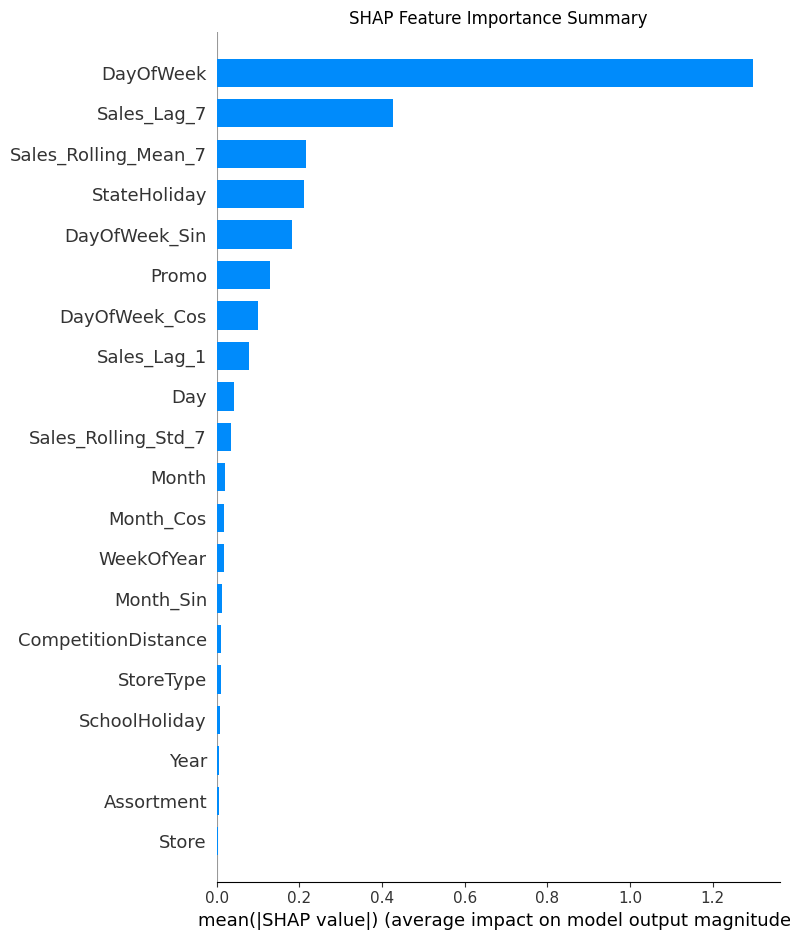

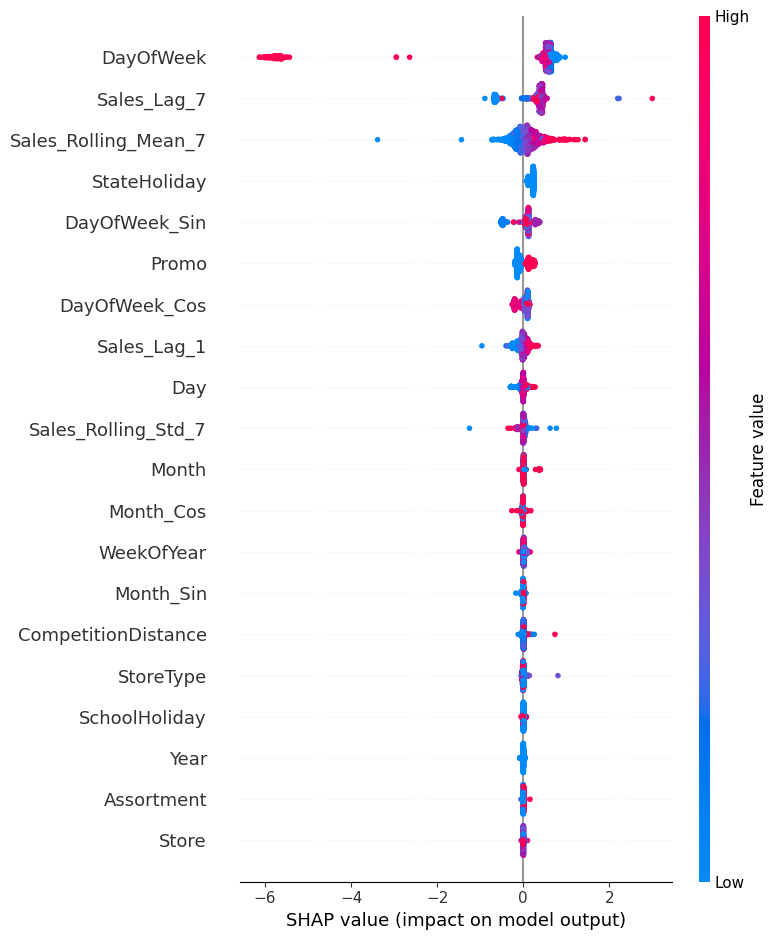

In [47]:
import shap
import matplotlib.pyplot as plt

print("\n--- Step 4: SHAP Feature Importance ---")

# Load JS visualization code to notebook
shap.initjs()
explainer = shap.TreeExplainer(final_model)

X_test_sample = X_test.sample(1000, random_state=42)
shap_values = explainer.shap_values(X_test_sample)
plt.figure(figsize=(10, 6))
plt.title("SHAP Feature Importance Summary")
shap.summary_plot(shap_values, X_test_sample, plot_type="bar")
plt.show()

# Detailed dot plot
shap.summary_plot(shap_values, X_test_sample)


Cell 5: Error Analysis
Implemented Requirements:

We look at the “Residuals” (Difference between Actual and Predicted). Large residuals mean the model failed. We investigate if these failures happened on Holidays or Promos.

In [48]:
print("\n--- Step 5: Error Analysis ---")

#analysis dataframe
analysis_df = X_test.copy()
analysis_df['Actual_Sales'] = y_test_real
analysis_df['Predicted_Sales'] = y_pred_real_xgb
analysis_df['Error'] = analysis_df['Actual_Sales'] - analysis_df['Predicted_Sales']
analysis_df['Abs_Error'] = abs(analysis_df['Error'])

# 1. Identify Worst Predictions (Top 5 Biggest Errors)
worst_predictions = analysis_df.sort_values('Abs_Error', ascending=False).head(5)

print("Top 5 Worst Predictions (Where model failed):")
print(worst_predictions[['DayOfWeek', 'Promo', 'StateHoliday', 'Actual_Sales', 'Predicted_Sales', 'Abs_Error']])

# 2. Analyze bias
mean_error = analysis_df['Error'].mean()
print(f"\nMean Error (Bias): {mean_error:.2f}")
if mean_error > 0:
    print("Interpretation: On average, the model UNDER-predicts sales.")
else:
    print("Interpretation: On average, the model OVER-predicts sales.")

# 3. Check error on Holidays vs Non-Holidays
#(StateHoliday is '0' for no holiday, '1' for holiday)
holiday_error = analysis_df[analysis_df['StateHoliday'] != 0]['Abs_Error'].mean()
regular_error = analysis_df[analysis_df['StateHoliday'] == 0]['Abs_Error'].mean()

print(f"\nMean Absolute Error on Holidays: {holiday_error:.2f}")
print(f"Mean Absolute Error on Regular Days: {regular_error:.2f}")



--- Step 5: Error Analysis ---
Top 5 Worst Predictions (Where model failed):
         DayOfWeek  Promo  StateHoliday  Actual_Sales  Predicted_Sales  \
973234           0      0             0       41551.0     13049.523438   
980989           0      1             0        6125.0     30307.033203   
980511           0      1             0       29161.0      9032.050781   
1004419          0      0             0       23081.0      4004.292969   
988901           0      0             0       27330.0     10629.935547   

            Abs_Error  
973234   28501.476562  
980989   24182.033203  
980511   20128.949219  
1004419  19076.707031  
988901   16700.064453  

Mean Error (Bias): 35.02
Interpretation: On average, the model UNDER-predicts sales.

Mean Absolute Error on Holidays: nan
Mean Absolute Error on Regular Days: 652.51
